done


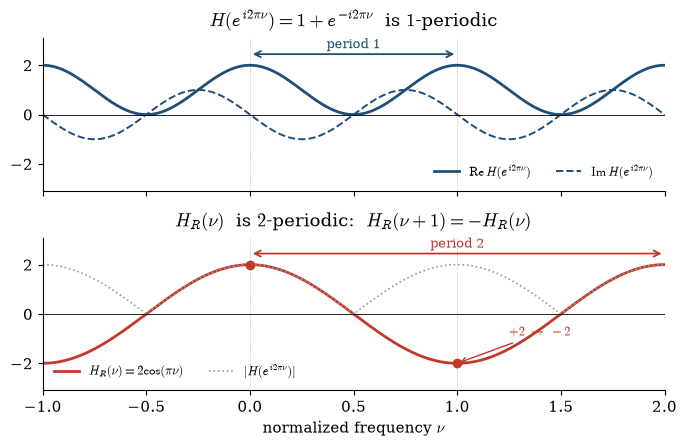

In [3]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "mathtext.fontset": "cm",
    "font.family": "serif",
})

nu = np.linspace(-1.0, 2.0, 2000)
H = 1 + np.exp(-2j * np.pi * nu)      # h = [1, 1], N = 2, beta = 1/2
HR = 2 * np.cos(np.pi * nu)           # real amplitude function

fig, ax = plt.subplots(2, 1, figsize=(7.0, 4.6), sharex=True)

C1, C2, CG = "#1f4e79", "#c0392b", "#999999"

# --- top: H(e^{i2 pi nu}) is 1-periodic -------------------------------------
ax[0].plot(nu, H.real, color=C1, lw=2, label=r"$\mathrm{Re}\,H(e^{i2\pi\nu})$")
ax[0].plot(nu, H.imag, color=C1, lw=1.4, ls="--", label=r"$\mathrm{Im}\,H(e^{i2\pi\nu})$")
ax[0].set_title(r"$H(e^{i2\pi\nu})=1+e^{-i2\pi\nu}$  is $1$-periodic", pad=8)
ax[0].set_ylim(-3.1, 3.1)
ax[0].legend(loc="lower right", frameon=False, fontsize=9, ncol=2)

# --- bottom: H_R(nu) is 2-periodic ------------------------------------------
ax[1].plot(nu, HR, color=C2, lw=2, label=r"$H_R(\nu)=2\cos(\pi\nu)$")
ax[1].plot(nu, np.abs(H), color=CG, lw=1.2, ls=":", label=r"$|H(e^{i2\pi\nu})|$")
ax[1].set_title(r"$H_R(\nu)$  is $2$-periodic:  $H_R(\nu+1)=-H_R(\nu)$", pad=8)
ax[1].set_ylim(-3.1, 3.1)
ax[1].set_xlabel(r"normalized frequency $\nu$")
ax[1].legend(loc="lower left", frameon=False, fontsize=9, ncol=2)

# period markers
for a, per, col in zip(ax, (1, 2), (C1, C2)):
    a.axhline(0, color="k", lw=0.6)
    for k in np.arange(-1, 2.1, 1.0):
        a.axvline(k, color="k", lw=0.5, ls=":", alpha=0.4)
    a.set_xlim(-1, 2)
    a.set_xticks([-1, -0.5, 0, 0.5, 1, 1.5, 2])
    # period arrow
    y = 2.45
    a.annotate("", xy=(per, y), xytext=(0, y),
        arrowprops=dict(arrowstyle="<->", color=col, lw=1.3))
    a.text(per / 2, y + 0.12, f"period {per}", color=col,
        ha="center", va="bottom", fontsize=9)

# highlight the sign flip
ax[1].plot([0, 1], [2, -2], "o", color=C2, ms=6)
ax[1].annotate(r"$+2 \;\rightarrow\; -2$", xy=(1, -2), xytext=(1.25, -0.9),
            color=C2, fontsize=9,
            arrowprops=dict(arrowstyle="->", color=C2, lw=1))

fig.tight_layout()
fig.savefig(f"./images/cm02_periodicity_HR.svg", dpi=200, bbox_inches="tight")
print("done")